In [1]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Importing the data
df = pd.read_csv("orders_population.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/orders_population.csv'

TRUE population mean order value = Rs 457.421


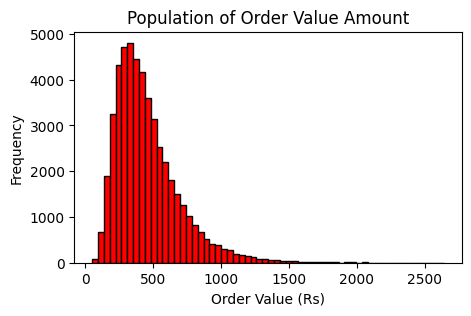

In [ ]:
# Getting the details
true_mean = df['order_value_inr'].mean()
print(f'TRUE population mean order value = Rs {true_mean:.3f}')

# Plot
plt.figure(figsize = (5, 3))
plt.hist(df['order_value_inr'], bins = 60, color = 'red', edgecolor = 'black')
plt.title('Population of Order Value Amount')
plt.xlabel('Order Value (Rs)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Sampling -> Why method matters ?
sample = df.sample(100, random_state = 5)
print(f'Sample Mean = Rs {sample['order_value_inr'].mean():.3f}')
print(f'TRUE population mean order value = Rs {true_mean:.3f}')

Sample Mean = Rs 435.890
TRUE population mean order value = Rs 457.421


In [ ]:
# Sample bias demo ->
biased = df[df['region'] == 'West'].sample(100, random_state = 5)
print(f'Sample Mean = Rs {biased['order_value_inr'].mean():.3f}')
print(f'TRUE population mean order value = Rs {true_mean:.3f}')

Sample Mean = Rs 453.210
TRUE population mean order value = Rs 457.421


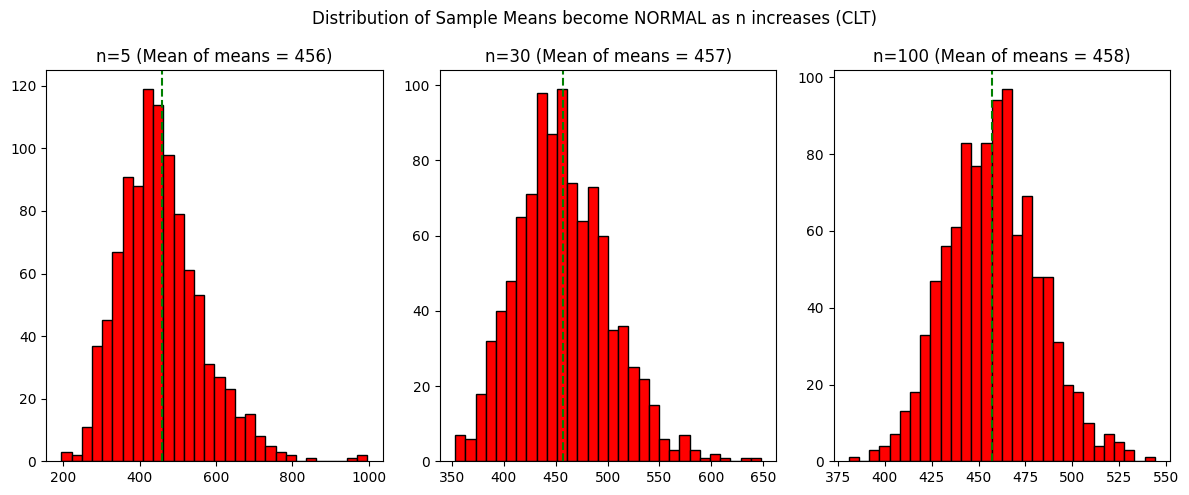

In [ ]:
# The Central Limit Theorem ->
def sampling_distribution(n, reps = 1000):
    return np.array([df['order_value_inr'].sample(n).mean() for _ in range(reps)])

fig, axes = plt.subplots(1, 3, figsize = (12, 5))
for ax, n in zip(axes, [5, 30, 100]):
    means = sampling_distribution(n)
    ax.hist(means, bins = 30, color = 'red', edgecolor = 'black')
    ax.axvline(true_mean, color = 'green', ls = '--')
    ax.set_title(f'n={n} (Mean of means = {means.mean():.0f})')
plt.suptitle('Distribution of Sample Means become NORMAL as n increases (CLT)')
plt.tight_layout()
plt.show()

In [ ]:
# Sampling Error
n = 100
s = sample['order_value_inr'].std()
se = s / np.sqrt(n)
print(f"Sample Std (s) = Rs {s:.3f}")
print(f"Standard Error = {s:.2f}/sqrt({n}) = Rs {se:.2f}")

Sample Std (s) = Rs 217.324
Standard Error = 217.32/sqrt(100) = Rs 21.73


In [ ]:
# Confidence Intervals
n = 100
samp = df['order_value_inr'].sample(n, random_state = 5)
m = samp.mean()
se = samp.std() / np.sqrt(n)
lo, hi = m - 1.96*se, m + 1.96*se

print(f'Sample Mean : Rs {m:.2f}')
print(f'95% CI : [Rs {lo:.2f}, Rs {hi:.2f}]')
print(f'True Mean : Rs {true_mean:.3f}')
print(f'True Mean inside CI?', lo <= true_mean <= hi)

Sample Mean : Rs 435.89
95% CI : [Rs 393.29, Rs 478.49]
True Mean : Rs 457.421
True Mean inside CI? True
